# Tablero de Mando - Análisis Vintage de Mora Crediticia CA

Este notebook ejecuta el pipeline completo de análisis vintage y presenta los resultados clave.

**Pasos:**
1. Consolidar archivos de otorgamientos
2. Generar matriz vintage
3. Visualizar curvas vintage
4. Resumen ejecutivo

---
## 0. Setup

In [19]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

# Configurar rutas
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# ---------------------------------------------------------------------------
# PARÁMETROS CONFIGURABLES (modificar acá)
# ---------------------------------------------------------------------------
N_DESTACAR = 5                  # Cantidad de últimas cohortes a resaltar
COLOR_2024 = "#2171b5"          # Color para cohortes 2024 (azul)
COLOR_2025 = "#e6550d"          # Color para cohortes 2025 (naranja)
ALPHA_INDIVIDUAL = 0.18         # Transparencia de curvas individuales
ALPHA_HIGHLIGHT = 0.85          # Transparencia de las curvas destacadas

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Cohortes a resaltar: últimas {N_DESTACAR}")

Raíz del proyecto: d:\Python\Vintage Saldo (moroso-vencido)
Cohortes a resaltar: últimas 5


---
## 1. Consolidar archivos de otorgamientos

In [20]:
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "consolidar_vintage.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

ConsolidaciÃ³n de datos para AnÃ¡lisis Vintage
Leyendo archivo: CA otorgamientos 2022-2025.csv
  1225 filas leÃ­das
  Columnas normalizadas: ['cohorte', 'id_tie_mes', 'cantidad_operaciones', 'total_vencido', 'total_pagado', 'moroso', 'indice']

Archivo consolidado generado: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\vintage_consolidado.csv
Total de filas: 1225
Cohortes encontradas: ['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
Rango de MOB: 1 - 49

Columnas del archivo de salida:
  ['coho

In [21]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, "vintage_consolidado.csv"), sep=";", decimal=",")
print(f"Registros: {len(df)} | Cohortes: {df['cohorte'].nunique()} | MOB máximo: {df['mob'].max()}")
df.head(10)

Registros: 1225 | Cohortes: 49 | MOB máximo: 49


,cohorte,id_tie_mes,cantidad_operaciones,total_vencido,total_pagado,moroso,indice,mob
0,2022-01,2022-02,44576,2.097464e+08,1.844061e+08,2.534025e+07,0.120814,1
1,2022-01,2022-03,44576,5.312576e+08,4.697207e+08,6.153697e+07,0.115833,2
2,2022-01,2022-04,44576,8.544663e+08,7.533539e+08,1.011124e+08,0.118334,3
3,2022-01,2022-05,44576,1.184661e+09,1.031401e+09,1.532596e+08,0.129370,4
4,2022-01,2022-06,44576,1.517046e+09,1.312900e+09,2.041466e+08,0.134568,5
5,2022-01,2022-07,44576,1.837591e+09,1.596620e+09,2.409704e+08,0.131134,6
6,2022-01,2022-08,44576,2.202617e+09,1.855690e+09,3.469271e+08,0.157507,7
7,2022-01,2022-09,44576,2.488410e+09,2.107140e+09,3.812697e+08,0.153218,8
8,2022-01,2022-10,44576,2.801035e+09,2.348530e+09,4.525046e+08,0.161549,9
9,2022-01,2022-11,44576,3.051926e+09,2.579395e+09,4.725308e+08,0.154830,10


---
## 2. Generar matriz vintage

In [22]:
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "generar_matriz_vintage.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)

GeneraciÃ³n de Matriz Vintage
Archivo leÃ­do: 1225 filas, 49 cohortes

Matriz vintage generada: 49 cohortes x 49 meses

Cohortes: ['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01']
MOBs: ['MOB_1', 'MOB_2', 'MOB_3', 'MOB_4', 'MOB_5', 'MOB_6', 'MOB_7', 'MOB_8', 'MOB_9', 'MOB_10', 'MOB_11', 'MOB_12', 'MOB_13', 'MOB_14', 'MOB_15', 'MOB_16', 'MOB_17', 'MOB_18', 'MOB_19', 'MOB_20', 'MOB_21', 'MOB_22', 'MOB_23', 'MOB_24', 'MOB_25', 'MOB_26', 'MOB_27', 'MOB_28', 'MOB_29', 'MOB_30', 'MOB_31', 'MOB_32', 'MOB_33', 'M

In [23]:
matriz = pd.read_csv(os.path.join(PROCESSED_DIR, "matriz_vintage.csv"), sep=";", decimal=",", index_col=0)

# Mostrar con formato porcentaje
matriz.style.format("{:.2%}", na_rep="-").background_gradient(cmap="RdYlGn_r", axis=None)

,MOB_1,MOB_2,MOB_3,MOB_4,MOB_5,MOB_6,MOB_7,MOB_8,MOB_9,MOB_10,MOB_11,MOB_12,MOB_13,MOB_14,MOB_15,MOB_16,MOB_17,MOB_18,MOB_19,MOB_20,MOB_21,MOB_22,MOB_23,MOB_24,MOB_25,MOB_26,MOB_27,MOB_28,MOB_29,MOB_30,MOB_31,MOB_32,MOB_33,MOB_34,MOB_35,MOB_36,MOB_37,MOB_38,MOB_39,MOB_40,MOB_41,MOB_42,MOB_43,MOB_44,MOB_45,MOB_46,MOB_47,MOB_48,MOB_49
cohorte,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01,12.08%,11.58%,11.83%,12.94%,13.46%,13.11%,15.75%,15.32%,16.15%,15.48%,14.50%,13.75%,13.30%,12.64%,12.23%,11.78%,11.22%,10.79%,10.55%,10.38%,10.16%,9.96%,9.77%,9.62%,9.50%,9.35%,9.26%,9.15%,9.02%,8.93%,8.85%,8.78%,8.69%,8.63%,8.56%,8.52%,8.47%,8.42%,8.38%,8.32%,8.29%,8.26%,8.24%,8.22%,8.20%,8.18%,8.16%,8.15%,8.13%
2022-02,11.61%,11.40%,11.81%,12.68%,12.55%,12.80%,12.82%,16.30%,15.87%,14.92%,14.13%,13.58%,12.81%,12.28%,11.84%,11.24%,10.75%,10.46%,10.22%,9.97%,9.75%,9.54%,9.38%,9.26%,9.08%,8.96%,8.87%,8.77%,8.63%,8.55%,8.48%,8.40%,8.33%,8.26%,8.20%,8.15%,8.08%,8.04%,8.00%,7.96%,7.93%,7.90%,7.89%,7.86%,7.84%,7.82%,7.81%,7.80%,-
2022-03,11.09%,11.43%,11.16%,11.64%,12.92%,13.00%,14.02%,16.17%,15.20%,14.43%,13.94%,13.17%,12.58%,12.10%,11.53%,10.99%,10.62%,10.35%,10.06%,9.80%,9.54%,9.39%,9.27%,9.13%,9.01%,8.90%,8.80%,8.69%,8.59%,8.52%,8.43%,8.35%,8.28%,8.22%,8.19%,8.14%,8.10%,8.07%,8.02%,8.00%,7.98%,7.94%,7.92%,7.90%,7.89%,7.88%,7.86%,-,-
2022-04,12.15%,11.05%,10.34%,12.03%,12.65%,12.94%,15.33%,14.61%,15.03%,14.63%,13.84%,13.26%,12.68%,12.08%,11.46%,11.07%,10.76%,10.40%,10.06%,9.77%,9.55%,9.39%,9.21%,9.08%,8.94%,8.78%,8.66%,8.57%,8.49%,8.40%,8.32%,8.23%,8.17%,8.13%,8.09%,8.05%,8.01%,7.96%,7.93%,7.91%,7.89%,7.87%,7.85%,7.83%,7.83%,7.81%,-,-,-
2022-05,10.65%,9.48%,9.99%,11.29%,11.90%,12.31%,11.78%,14.30%,14.08%,13.25%,12.69%,12.11%,11.43%,10.86%,10.53%,10.22%,9.90%,9.54%,9.18%,8.96%,8.83%,8.64%,8.47%,8.31%,8.12%,7.99%,7.89%,7.80%,7.73%,7.67%,7.62%,7.58%,7.54%,7.52%,7.48%,7.43%,7.40%,7.38%,7.36%,7.34%,7.32%,7.31%,7.28%,7.27%,7.26%,-,-,-,-
2022-06,9.17%,9.96%,9.93%,10.89%,11.82%,11.58%,12.30%,14.48%,13.83%,13.28%,12.80%,12.09%,11.37%,10.98%,10.64%,10.32%,9.90%,9.51%,9.26%,9.08%,8.89%,8.74%,8.57%,8.41%,8.25%,8.11%,8.02%,7.93%,7.86%,7.79%,7.72%,7.67%,7.64%,7.60%,7.57%,7.53%,7.50%,7.46%,7.45%,7.42%,7.41%,7.37%,7.36%,7.35%,-,-,-,-,-
2022-07,11.39%,10.46%,10.59%,11.64%,11.35%,11.36%,14.10%,13.72%,13.13%,12.60%,11.85%,11.10%,10.73%,10.33%,9.98%,9.55%,9.17%,8.91%,8.77%,8.51%,8.34%,8.17%,8.01%,7.83%,7.70%,7.58%,7.50%,7.43%,7.35%,7.28%,7.22%,7.18%,7.15%,7.11%,7.06%,7.03%,6.99%,6.94%,6.91%,6.88%,6.82%,6.80%,6.78%,-,-,-,-,-,-
2022-08,10.13%,9.49%,9.71%,9.53%,9.96%,10.56%,12.53%,12.34%,11.90%,11.08%,10.28%,9.91%,9.51%,9.21%,8.79%,8.35%,8.10%,7.95%,7.71%,7.55%,7.40%,7.29%,7.14%,7.05%,6.95%,6.84%,6.78%,6.72%,6.67%,6.64%,6.60%,6.55%,6.52%,6.49%,6.45%,6.44%,6.41%,6.37%,6.34%,6.30%,6.28%,6.26%,-,-,-,-,-,-,-
2022-09,9.60%,9.38%,8.54%,9.11%,10.09%,10.27%,12.31%,11.91%,11.28%,10.42%,10.15%,9.69%,9.31%,8.83%,8.32%,8.06%,7.93%,7.69%,7.52%,7.39%,7.26%,7.09%,6.99%,6.92%,6.82%,6.75%,6.70%,6.64%,6.59%,6.55%,6.50%,6.44%,6.38%,6.31%,6.28%,6.25%,6.21%,6.18%,6.17%,6.15%,6.12%,-,-,-,-,-,-,-,-


---
## 3. Curvas Vintage

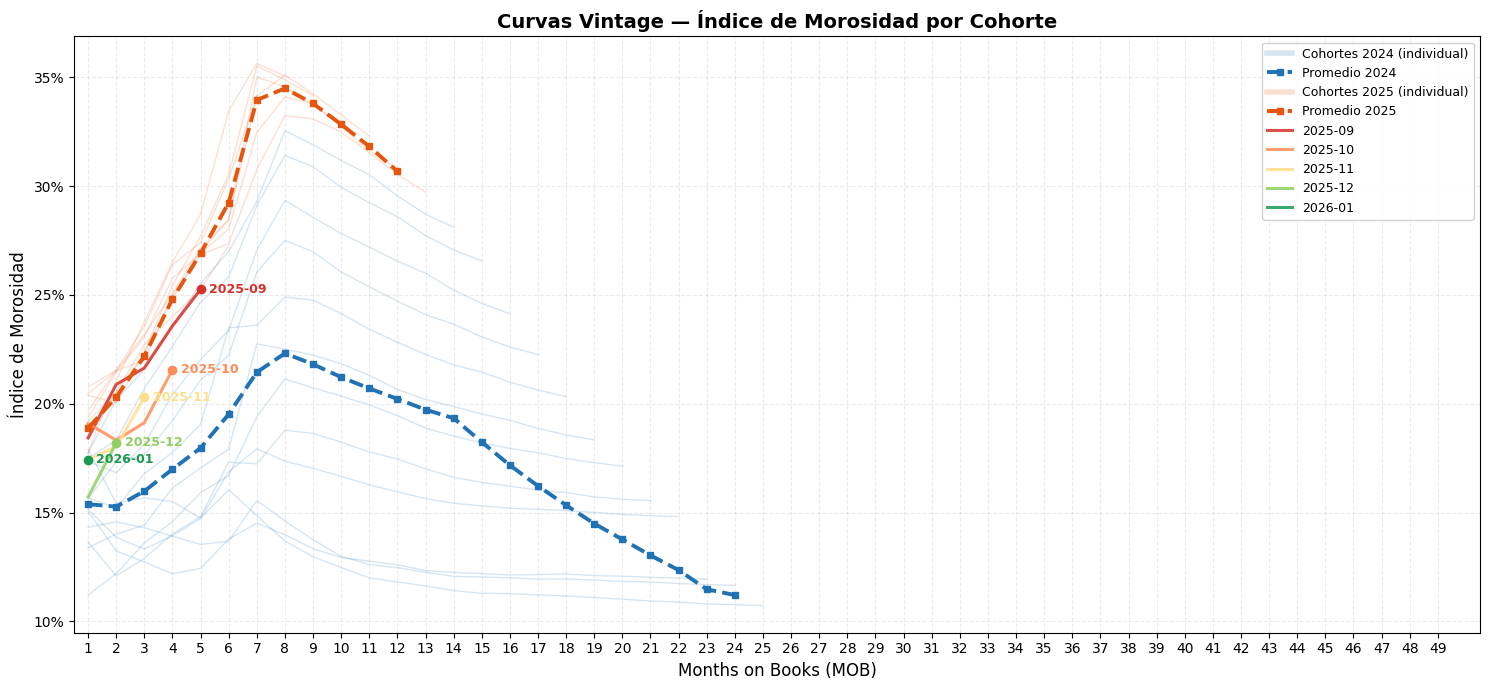

Gráfico guardado en reports/curvas_vintage.png


In [24]:
# Usa N_DESTACAR, COLOR_2024, COLOR_2025, ALPHA_INDIVIDUAL, ALPHA_HIGHLIGHT del Setup
LW_INDIVIDUAL = 1.0
LW_PROMEDIO = 2.8
LW_HIGHLIGHT = 2.2

# Paleta de colores distinguibles para las últimas N cohortes destacadas
COLORES_DESTACADAS = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

cohortes_ordenadas = sorted(matriz.index)
ultimas_n = cohortes_ordenadas[-N_DESTACAR:]
color_por_cohorte = {c: COLORES_DESTACADAS[i % len(COLORES_DESTACADAS)] for i, c in enumerate(ultimas_n)}

cohortes_2024 = [c for c in cohortes_ordenadas if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ordenadas if c.startswith("2025")]
cohortes_2026 = [c for c in cohortes_ordenadas if c.startswith("2026")]

def extraer_serie(cohorte):
    valores = matriz.loc[cohorte].dropna()
    mobs = [int(c.replace("MOB_", "")) for c in valores.index]
    return mobs, valores.values

def promedio_anio(cohortes):
    mob_max = max(int(c.replace("MOB_", "")) for c in matriz.columns)
    mobs_out, vals_out = [], []
    for m in range(1, mob_max + 1):
        col = f"MOB_{m}"
        vals = matriz.loc[cohortes, col].dropna()
        if len(vals) >= 2:
            mobs_out.append(m)
            vals_out.append(vals.mean())
    return mobs_out, vals_out

prom_mobs_2024, prom_vals_2024 = promedio_anio(cohortes_2024)
prom_mobs_2025, prom_vals_2025 = promedio_anio(cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])

fig, ax = plt.subplots(figsize=(15, 7))

for cohorte in cohortes_2024:
    mobs, vals = extraer_serie(cohorte)
    es_destacada = cohorte in ultimas_n
    ax.plot(mobs, vals,
            color=color_por_cohorte[cohorte] if es_destacada else COLOR_2024,
            alpha=ALPHA_HIGHLIGHT if es_destacada else ALPHA_INDIVIDUAL,
            linewidth=LW_HIGHLIGHT if es_destacada else LW_INDIVIDUAL,
            zorder=3 if es_destacada else 1)

for cohorte in cohortes_2025:
    mobs, vals = extraer_serie(cohorte)
    es_destacada = cohorte in ultimas_n
    ax.plot(mobs, vals,
            color=color_por_cohorte[cohorte] if es_destacada else COLOR_2025,
            alpha=ALPHA_HIGHLIGHT if es_destacada else ALPHA_INDIVIDUAL,
            linewidth=LW_HIGHLIGHT if es_destacada else LW_INDIVIDUAL,
            zorder=3 if es_destacada else 1)

for cohorte in cohortes_2026:
    mobs, vals = extraer_serie(cohorte)
    es_destacada = cohorte in ultimas_n
    ax.plot(mobs, vals,
            color=color_por_cohorte[cohorte] if es_destacada else "gray",
            alpha=ALPHA_HIGHLIGHT if es_destacada else ALPHA_INDIVIDUAL,
            linewidth=LW_HIGHLIGHT if es_destacada else LW_INDIVIDUAL,
            zorder=3 if es_destacada else 1)

if prom_mobs_2024:
    ax.plot(prom_mobs_2024, prom_vals_2024,
            color=COLOR_2024, linewidth=LW_PROMEDIO, linestyle="--",
            marker="s", markersize=5, zorder=4)

if prom_mobs_2025:
    ax.plot(prom_mobs_2025, prom_vals_2025,
            color=COLOR_2025, linewidth=LW_PROMEDIO, linestyle="--",
            marker="s", markersize=5, zorder=4)

for cohorte in ultimas_n:
    mobs, vals = extraer_serie(cohorte)
    color = color_por_cohorte[cohorte]
    ax.annotate(cohorte, xy=(mobs[-1], vals[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center",
                zorder=5)
    ax.plot(mobs[-1], vals[-1], "o", color=color, markersize=6, zorder=5)

ax.set_xlabel("Months on Books (MOB)", fontsize=12)
ax.set_ylabel("Índice de Morosidad", fontsize=12)
ax.set_title("Curvas Vintage — Índice de Morosidad por Cohorte", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(range(1, int(df["mob"].max()) + 1))
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_xlim(0.5, int(df["mob"].max()) + 1.5)

legend_elements = [
    Line2D([0], [0], color=COLOR_2024, alpha=ALPHA_INDIVIDUAL, lw=4, label="Cohortes 2024 (individual)"),
    Line2D([0], [0], color=COLOR_2024, lw=LW_PROMEDIO, ls="--", marker="s", markersize=5, label="Promedio 2024"),
    Line2D([0], [0], color=COLOR_2025, alpha=ALPHA_INDIVIDUAL, lw=4, label="Cohortes 2025 (individual)"),
]
if prom_mobs_2025:
    legend_elements.append(
        Line2D([0], [0], color=COLOR_2025, lw=LW_PROMEDIO, ls="--", marker="s", markersize=5, label="Promedio 2025"))
for cohorte in ultimas_n:
    legend_elements.append(
        Line2D([0], [0], color=color_por_cohorte[cohorte], lw=LW_HIGHLIGHT, alpha=ALPHA_HIGHLIGHT, label=cohorte))

ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "curvas_vintage.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/curvas_vintage.png")

---
## 3b. Factores de Desarrollo

El factor de desarrollo mide cuánto cambia el índice de morosidad de un MOB al siguiente:
**factor = índice(MOB_n) / índice(MOB_n-1)**

- **Factor > 1**: la mora crece → el deterioro se acelera
- **Factor = 1**: la mora se mantiene estable
- **Factor < 1**: la mora se reduce → la cartera se estabiliza o recupera

In [25]:

# Ejecutar script de factores de desarrollo
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "generar_factores_desarrollo.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)


GeneraciÃ³n de Factores de Desarrollo
Matriz leÃ­da: 49 cohortes x 49 MOBs

Factores generados: 49 cohortes x 48 transiciones
Archivo guardado: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\factores_desarrollo.csv

Vista previa:
          1->2   2->3   3->4   4->5   5->6   6->7   7->8   8->9
cohorte                                                        
2022-01 0.9588 1.0216 1.0933 1.0402 0.9745 1.2011 0.9728 1.0544
2022-02 0.9823 1.0363 1.0730 0.9899 1.0199 1.0019 1.2710 0.9738
2022-03 1.0304 0.9762 1.0434 1.1103 1.0055 1.0789 1.1533 0.9401
2022-04 0.9091 0.9359 1.1630 1.0519 1.0231 1.1841 0.9530 1.0291
2022-05 0.8905 1.0537 1.1300 1.0535 1.0347 0.9571 1.2135 0.9848
2022-06 1.0860 0.9970 1.0970 1.0846 0.9797 1.0625 1.1770 0.9552
2022-07 0.9187 1.0128 1.0988 0.9747 1.0016 1.2409 0.9727 0.9571
2022-08 0.9367 1.0229 0.9821 1.0451 1.0595 1.1869 0.9845 0.9650
2022-09 0.9771 0.9106 1.0661 1.1076 1.0181 1.1981 0.9677 0.9469
2022-10 0.8349 1.0029 1.1428 1.0112 1.0707 0.9948 1.1362 

In [26]:

# Leer factores y mostrar como heatmap con formato condicional
factores = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_desarrollo.csv"), sep=";", decimal=",", index_col=0)

# Colorear: rojo si > 1 (mora crece), verde si < 1 (mora baja), blanco en 1
factores.style.format("{:.3f}", na_rep="-").background_gradient(
    cmap="RdYlGn_r", vmin=0.90, vmax=1.30, axis=None
)


,1->2,2->3,3->4,4->5,5->6,6->7,7->8,8->9,9->10,10->11,11->12,12->13,13->14,14->15,15->16,16->17,17->18,18->19,19->20,20->21,21->22,22->23,23->24,24->25,25->26,26->27,27->28,28->29,29->30,30->31,31->32,32->33,33->34,34->35,35->36,36->37,37->38,38->39,39->40,40->41,41->42,42->43,43->44,44->45,45->46,46->47,47->48,48->49
cohorte,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01,0.959,1.022,1.093,1.040,0.974,1.201,0.973,1.054,0.958,0.937,0.948,0.967,0.951,0.968,0.963,0.953,0.962,0.978,0.984,0.979,0.980,0.981,0.985,0.987,0.984,0.990,0.988,0.986,0.990,0.991,0.992,0.990,0.994,0.992,0.995,0.995,0.994,0.996,0.993,0.996,0.997,0.997,0.997,0.998,0.998,0.998,0.999,0.998
2022-02,0.982,1.036,1.073,0.990,1.020,1.002,1.271,0.974,0.940,0.947,0.961,0.943,0.959,0.964,0.950,0.956,0.973,0.977,0.976,0.978,0.978,0.983,0.988,0.980,0.986,0.990,0.989,0.985,0.991,0.992,0.990,0.991,0.992,0.993,0.994,0.991,0.995,0.995,0.996,0.996,0.996,0.998,0.997,0.998,0.998,0.999,0.999,-
2022-03,1.030,0.976,1.043,1.110,1.006,1.079,1.153,0.940,0.949,0.966,0.945,0.955,0.962,0.952,0.954,0.966,0.975,0.972,0.973,0.974,0.984,0.988,0.985,0.986,0.988,0.990,0.987,0.988,0.992,0.990,0.990,0.991,0.993,0.996,0.995,0.994,0.996,0.994,0.998,0.997,0.995,0.997,0.998,0.998,0.999,0.998,-,-
2022-04,0.909,0.936,1.163,1.052,1.023,1.184,0.953,1.029,0.973,0.946,0.958,0.956,0.953,0.948,0.966,0.972,0.966,0.967,0.971,0.978,0.983,0.981,0.986,0.984,0.983,0.986,0.989,0.991,0.989,0.991,0.990,0.993,0.994,0.996,0.994,0.995,0.994,0.996,0.997,0.997,0.998,0.997,0.998,0.999,0.998,-,-,-
2022-05,0.891,1.054,1.130,1.053,1.035,0.957,1.214,0.985,0.941,0.958,0.955,0.944,0.950,0.970,0.970,0.969,0.963,0.963,0.976,0.986,0.978,0.980,0.981,0.978,0.984,0.988,0.989,0.990,0.992,0.994,0.994,0.996,0.997,0.994,0.994,0.996,0.997,0.997,0.998,0.998,0.998,0.996,0.998,0.999,-,-,-,-
2022-06,1.086,0.997,1.097,1.085,0.980,1.062,1.177,0.955,0.960,0.964,0.944,0.941,0.966,0.969,0.969,0.960,0.960,0.974,0.981,0.979,0.983,0.981,0.981,0.981,0.983,0.988,0.989,0.991,0.991,0.991,0.994,0.996,0.996,0.995,0.995,0.995,0.995,0.998,0.997,0.998,0.995,0.998,0.999,-,-,-,-,-
2022-07,0.919,1.013,1.099,0.975,1.002,1.241,0.973,0.957,0.960,0.940,0.936,0.967,0.962,0.967,0.957,0.960,0.972,0.984,0.970,0.980,0.980,0.980,0.977,0.984,0.984,0.989,0.991,0.989,0.991,0.992,0.994,0.996,0.995,0.992,0.996,0.995,0.993,0.996,0.995,0.992,0.998,0.997,-,-,-,-,-,-
2022-08,0.937,1.023,0.982,1.045,1.059,1.187,0.985,0.965,0.930,0.928,0.964,0.960,0.968,0.954,0.950,0.970,0.981,0.970,0.980,0.980,0.985,0.980,0.987,0.986,0.985,0.991,0.991,0.992,0.995,0.994,0.993,0.994,0.995,0.995,0.998,0.995,0.994,0.996,0.994,0.997,0.996,-,-,-,-,-,-,-
2022-09,0.977,0.911,1.066,1.108,1.018,1.198,0.968,0.947,0.924,0.974,0.955,0.960,0.948,0.943,0.968,0.984,0.970,0.977,0.983,0.982,0.977,0.986,0.991,0.985,0.990,0.992,0.991,0.992,0.994,0.992,0.991,0.991,0.990,0.995,0.996,0.994,0.995,0.997,0.997,0.996,-,-,-,-,-,-,-,-


### Curvas de factores de desarrollo por transición MOB

Cada línea muestra cómo evoluciona el factor de desarrollo (mes a mes) para una cohorte.
La **línea roja punteada en 1.0** es el umbral: por encima la mora crece, por debajo se estabiliza.

Si todas las cohortes cruzan el umbral en un MOB similar, el patrón es **estructural**.
Si hay cohortes que divergen, hay un **cambio de tendencia** en la calidad crediticia.

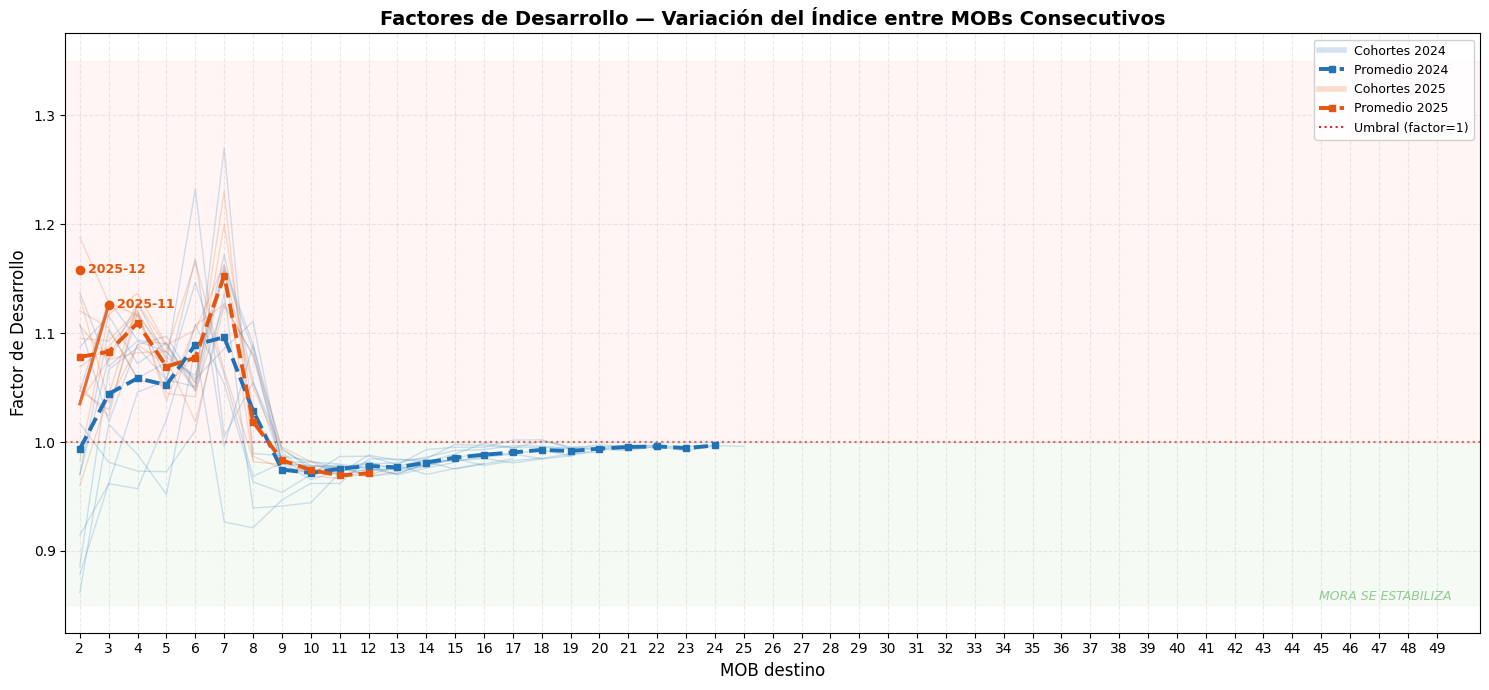

Gráfico guardado en reports/factores_desarrollo.png


In [27]:
from matplotlib.lines import Line2D
import numpy as np

COLOR_2024 = "#2171b5"
COLOR_2025 = "#e6550d"
ALPHA_IND = 0.20
ALPHA_HL = 0.85
N_DESTACAR = 3

cohortes_ord = sorted(factores.index)
ultimas_n = cohortes_ord[-N_DESTACAR:]
cohortes_2024 = [c for c in cohortes_ord if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ord if c.startswith("2025")]

def extraer_factores(cohorte):
    vals = factores.loc[cohorte].dropna()
    if len(vals) == 0:
        return [], np.array([])
    mobs = [int(t.split("->")[1]) for t in vals.index]
    return mobs, vals.values

def promedio_factores(cohortes):
    mobs_out, vals_out = [], []
    for col in factores.columns:
        vals = factores.loc[cohortes, col].dropna()
        if len(vals) >= 2:
            mob_dest = int(col.split("->")[1])
            mobs_out.append(mob_dest)
            vals_out.append(vals.mean())
    return mobs_out, vals_out

prom_m24, prom_v24 = promedio_factores(cohortes_2024)
prom_m25, prom_v25 = promedio_factores(cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])

fig, ax = plt.subplots(figsize=(15, 7))

ax.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7, zorder=0)
ax.axhspan(1.0, 1.35, alpha=0.04, color="red", zorder=0)
ax.axhspan(0.85, 1.0, alpha=0.04, color="green", zorder=0)

for cohorte in cohortes_2024:
    mobs, vals = extraer_factores(cohorte)
    if not mobs:
        continue
    hl = cohorte in ultimas_n
    ax.plot(mobs, vals, color=COLOR_2024,
            alpha=ALPHA_HL if hl else ALPHA_IND,
            linewidth=2.2 if hl else 1.0, zorder=3 if hl else 1)

for cohorte in cohortes_2025:
    mobs, vals = extraer_factores(cohorte)
    if not mobs:
        continue
    hl = cohorte in ultimas_n
    ax.plot(mobs, vals, color=COLOR_2025,
            alpha=ALPHA_HL if hl else ALPHA_IND,
            linewidth=2.2 if hl else 1.0, zorder=3 if hl else 1)

if prom_m24:
    ax.plot(prom_m24, prom_v24, color=COLOR_2024, linewidth=2.8,
            linestyle="--", marker="s", markersize=5, zorder=4)
if prom_m25:
    ax.plot(prom_m25, prom_v25, color=COLOR_2025, linewidth=2.8,
            linestyle="--", marker="s", markersize=5, zorder=4)

for cohorte in ultimas_n:
    mobs, vals = extraer_factores(cohorte)
    if not mobs:
        continue
    color = COLOR_2024 if cohorte.startswith("2024") else COLOR_2025
    ax.annotate(cohorte, xy=(mobs[-1], vals[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center", zorder=5)
    ax.plot(mobs[-1], vals[-1], "o", color=color, markersize=6, zorder=5)

ax.text(0.98, 0.95, "MORA CRECE", transform=ax.transAxes, fontsize=9,
        ha="right", va="top", color="#d62728", alpha=0.5, fontstyle="italic")
ax.text(0.98, 0.05, "MORA SE ESTABILIZA", transform=ax.transAxes, fontsize=9,
        ha="right", va="bottom", color="#2ca02c", alpha=0.5, fontstyle="italic")

ax.set_xlabel("MOB destino", fontsize=12)
ax.set_ylabel("Factor de Desarrollo", fontsize=12)
ax.set_title("Factores de Desarrollo — Variación del Índice entre MOBs Consecutivos",
             fontsize=14, fontweight="bold")
mob_max = max(int(c.split("->")[1]) for c in factores.columns)
ax.set_xticks(range(2, mob_max + 1))
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_xlim(1.5, mob_max + 1.5)

legend_elements = [
    Line2D([0], [0], color=COLOR_2024, alpha=ALPHA_IND, lw=4, label="Cohortes 2024"),
    Line2D([0], [0], color=COLOR_2024, lw=2.8, ls="--", marker="s", markersize=5, label="Promedio 2024"),
    Line2D([0], [0], color=COLOR_2025, alpha=ALPHA_IND, lw=4, label="Cohortes 2025"),
]
if prom_m25:
    legend_elements.append(
        Line2D([0], [0], color=COLOR_2025, lw=2.8, ls="--", marker="s", markersize=5, label="Promedio 2025"))
legend_elements.append(
    Line2D([0], [0], color="#d62728", lw=1.5, ls=":", label="Umbral (factor=1)"))

ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "factores_desarrollo.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/factores_desarrollo.png")

In [28]:
print("ANÁLISIS DE PUNTO DE QUIEBRE")
print("=" * 60)
print("MOB donde el factor promedio baja de 1.0 (mora empieza a estabilizarse):\n")

for year, cohs in [("2024", cohortes_2024), ("2025", cohortes_2025)]:
    if len(cohs) < 2:
        continue
    print(f"  Promedio {year}:")
    for col in factores.columns:
        vals = factores.loc[cohs, col].dropna()
        if len(vals) >= 2:
            mean_val = vals.mean()
            mob_dest = col.split("->")[1]
            marker = " ◄ CRUCE" if abs(mean_val - 1.0) < 0.015 else ""
            zona = "▲" if mean_val > 1.0 else "▼"
            print(f"    MOB {mob_dest:>2s}: {mean_val:.4f} {zona}{marker}")

print("\n" + "=" * 60)
print("\nInterpretación:")
print("  ▲ Factor > 1: la mora sigue creciendo en esa transición")
print("  ▼ Factor < 1: la mora empieza a bajar en esa transición")
print("  ◄ CRUCE: punto donde el factor está muy cerca de 1 (cambio de tendencia)")


ANÁLISIS DE PUNTO DE QUIEBRE
MOB donde el factor promedio baja de 1.0 (mora empieza a estabilizarse):

  Promedio 2024:
    MOB  2: 0.9936 ▼ ◄ CRUCE
    MOB  3: 1.0442 ▲
    MOB  4: 1.0585 ▲
    MOB  5: 1.0523 ▲
    MOB  6: 1.0893 ▲
    MOB  7: 1.0962 ▲
    MOB  8: 1.0288 ▲
    MOB  9: 0.9747 ▼
    MOB 10: 0.9716 ▼
    MOB 11: 0.9754 ▼
    MOB 12: 0.9781 ▼
    MOB 13: 0.9767 ▼
    MOB 14: 0.9811 ▼
    MOB 15: 0.9857 ▼ ◄ CRUCE
    MOB 16: 0.9883 ▼ ◄ CRUCE
    MOB 17: 0.9904 ▼ ◄ CRUCE
    MOB 18: 0.9928 ▼ ◄ CRUCE
    MOB 19: 0.9917 ▼ ◄ CRUCE
    MOB 20: 0.9939 ▼ ◄ CRUCE
    MOB 21: 0.9954 ▼ ◄ CRUCE
    MOB 22: 0.9960 ▼ ◄ CRUCE
    MOB 23: 0.9944 ▼ ◄ CRUCE
    MOB 24: 0.9968 ▼ ◄ CRUCE
  Promedio 2025:
    MOB  2: 1.0780 ▲
    MOB  3: 1.0828 ▲
    MOB  4: 1.1093 ▲
    MOB  5: 1.0692 ▲
    MOB  6: 1.0772 ▲
    MOB  7: 1.1525 ▲
    MOB  8: 1.0186 ▲
    MOB  9: 0.9833 ▼
    MOB 10: 0.9744 ▼
    MOB 11: 0.9693 ▼
    MOB 12: 0.9713 ▼


Interpretación:
  ▲ Factor > 1: la mora sigue creciendo en 

---
## 3c. Velocidad de Mora (1ra derivada) y Diagnóstico de Fase

La **velocidad** mide el cambio absoluto del índice entre MOBs consecutivos:
`velocidad = índice(MOB_n) - índice(MOB_n-1)`

| Velocidad | Factor | Diagnóstico |
|-----------|--------|-------------|
| > 0 | > 1 y subiendo | **Aceleración**: deterioro se intensifica |
| > 0 | > 1 pero bajando hacia 1 | **Desaceleración**: mora crece pero cada vez más lento |
| ≈ 0 | ≈ 1 | **Plateau/Meseta**: la cosecha se estabilizó |
| < 0 | < 1 | **Curación**: la cosecha está mejorando |


In [29]:
result = subprocess.run(
    ["py", os.path.join(SRC_DIR, "generar_velocidad_mora.py")],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("ERROR:", result.stderr)


GeneraciÃ³n de Velocidad de Mora (1ra derivada)
Matriz leÃ­da: 49 cohortes x 49 MOBs

Velocidad generada: 49 cohortes x 48 transiciones
Archivo guardado: d:\Python\Vintage Saldo (moroso-vencido)\data\processed\velocidad_mora.csv

Vista previa (primeras 8 transiciones):
             1->2      2->3      3->4      4->5      5->6      6->7      7->8      8->9
cohorte                                                                                
2022-01 -0.004981  0.002501  0.011036  0.005198 -0.003435  0.026373 -0.004289  0.008331
2022-02 -0.002051  0.004140  0.008628 -0.001281  0.002494  0.000243  0.034750 -0.004272
2022-03  0.003374 -0.002720  0.004844  0.012839  0.000712  0.010260  0.021493 -0.009689
2022-04 -0.011043 -0.007085  0.016853  0.006247  0.002924  0.023834 -0.007198  0.004245
2022-05 -0.011657  0.005096  0.012990  0.006036  0.004131 -0.005278  0.025158 -0.002177
2022-06  0.007887 -0.000297  0.009634  0.009217 -0.002399  0.007234  0.021765 -0.006479
2022-07 -0.009257  0.00133

In [30]:
velocidad = pd.read_csv(os.path.join(PROCESSED_DIR, "velocidad_mora.csv"), sep=";", decimal=",", index_col=0)

# Heatmap: rojo si > 0 (mora crece), verde si < 0 (mora baja), blanco en 0
velocidad.style.format("{:.4f}", na_rep="-").background_gradient(
    cmap="RdYlGn_r", vmin=-0.02, vmax=0.04, axis=None
)


,1->2,2->3,3->4,4->5,5->6,6->7,7->8,8->9,9->10,10->11,11->12,12->13,13->14,14->15,15->16,16->17,17->18,18->19,19->20,20->21,21->22,22->23,23->24,24->25,25->26,26->27,27->28,28->29,29->30,30->31,31->32,32->33,33->34,34->35,35->36,36->37,37->38,38->39,39->40,40->41,41->42,42->43,43->44,44->45,45->46,46->47,47->48,48->49
cohorte,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01,-0.0050,0.0025,0.0110,0.0052,-0.0034,0.0264,-0.0043,0.0083,-0.0067,-0.0098,-0.0075,-0.0045,-0.0066,-0.0041,-0.0046,-0.0056,-0.0043,-0.0024,-0.0017,-0.0022,-0.0020,-0.0019,-0.0015,-0.0012,-0.0015,-0.0009,-0.0011,-0.0013,-0.0009,-0.0008,-0.0007,-0.0009,-0.0006,-0.0007,-0.0004,-0.0005,-0.0005,-0.0004,-0.0006,-0.0004,-0.0002,-0.0002,-0.0002,-0.0002,-0.0002,-0.0002,-0.0001,-0.0001
2022-02,-0.0021,0.0041,0.0086,-0.0013,0.0025,0.0002,0.0348,-0.0043,-0.0095,-0.0079,-0.0055,-0.0077,-0.0053,-0.0045,-0.0060,-0.0049,-0.0029,-0.0024,-0.0025,-0.0022,-0.0021,-0.0016,-0.0011,-0.0018,-0.0012,-0.0009,-0.0010,-0.0014,-0.0008,-0.0007,-0.0008,-0.0007,-0.0007,-0.0006,-0.0005,-0.0007,-0.0004,-0.0004,-0.0003,-0.0003,-0.0003,-0.0002,-0.0002,-0.0002,-0.0002,-0.0001,-0.0001,-
2022-03,0.0034,-0.0027,0.0048,0.0128,0.0007,0.0103,0.0215,-0.0097,-0.0077,-0.0049,-0.0077,-0.0059,-0.0047,-0.0058,-0.0053,-0.0037,-0.0027,-0.0028,-0.0027,-0.0026,-0.0015,-0.0012,-0.0014,-0.0013,-0.0011,-0.0009,-0.0011,-0.0010,-0.0007,-0.0008,-0.0008,-0.0007,-0.0006,-0.0003,-0.0004,-0.0005,-0.0003,-0.0005,-0.0002,-0.0002,-0.0004,-0.0002,-0.0001,-0.0002,-0.0001,-0.0002,-,-
2022-04,-0.0110,-0.0071,0.0169,0.0062,0.0029,0.0238,-0.0072,0.0042,-0.0040,-0.0080,-0.0058,-0.0058,-0.0060,-0.0063,-0.0039,-0.0031,-0.0036,-0.0034,-0.0029,-0.0022,-0.0016,-0.0018,-0.0013,-0.0014,-0.0016,-0.0012,-0.0009,-0.0008,-0.0009,-0.0008,-0.0009,-0.0006,-0.0005,-0.0003,-0.0004,-0.0004,-0.0005,-0.0003,-0.0002,-0.0002,-0.0001,-0.0002,-0.0002,-0.0001,-0.0002,-,-,-
2022-05,-0.0117,0.0051,0.0130,0.0060,0.0041,-0.0053,0.0252,-0.0022,-0.0083,-0.0056,-0.0058,-0.0068,-0.0058,-0.0033,-0.0031,-0.0031,-0.0037,-0.0036,-0.0022,-0.0013,-0.0019,-0.0017,-0.0016,-0.0018,-0.0013,-0.0010,-0.0009,-0.0008,-0.0006,-0.0004,-0.0005,-0.0003,-0.0002,-0.0004,-0.0004,-0.0003,-0.0002,-0.0002,-0.0002,-0.0002,-0.0001,-0.0003,-0.0002,-0.0001,-,-,-,-
2022-06,0.0079,-0.0003,0.0096,0.0092,-0.0024,0.0072,0.0218,-0.0065,-0.0055,-0.0048,-0.0071,-0.0071,-0.0039,-0.0034,-0.0033,-0.0041,-0.0040,-0.0025,-0.0018,-0.0019,-0.0015,-0.0016,-0.0016,-0.0016,-0.0014,-0.0009,-0.0009,-0.0007,-0.0007,-0.0007,-0.0005,-0.0003,-0.0003,-0.0004,-0.0004,-0.0003,-0.0003,-0.0001,-0.0003,-0.0002,-0.0004,-0.0001,-0.0001,-,-,-,-,-
2022-07,-0.0093,0.0013,0.0105,-0.0029,0.0002,0.0274,-0.0038,-0.0059,-0.0053,-0.0075,-0.0076,-0.0037,-0.0040,-0.0034,-0.0043,-0.0039,-0.0025,-0.0014,-0.0026,-0.0017,-0.0017,-0.0016,-0.0018,-0.0013,-0.0013,-0.0008,-0.0007,-0.0008,-0.0007,-0.0006,-0.0005,-0.0003,-0.0004,-0.0005,-0.0003,-0.0004,-0.0005,-0.0003,-0.0003,-0.0006,-0.0002,-0.0002,-,-,-,-,-,-
2022-08,-0.0064,0.0022,-0.0017,0.0043,0.0059,0.0197,-0.0019,-0.0043,-0.0083,-0.0080,-0.0037,-0.0039,-0.0030,-0.0042,-0.0044,-0.0025,-0.0015,-0.0024,-0.0016,-0.0015,-0.0011,-0.0015,-0.0009,-0.0010,-0.0011,-0.0006,-0.0006,-0.0005,-0.0003,-0.0004,-0.0005,-0.0004,-0.0003,-0.0003,-0.0001,-0.0004,-0.0004,-0.0003,-0.0004,-0.0002,-0.0002,-,-,-,-,-,-,-
2022-09,-0.0022,-0.0084,0.0056,0.0098,0.0018,0.0203,-0.0040,-0.0063,-0.0086,-0.0027,-0.0046,-0.0038,-0.0048,-0.0051,-0.0027,-0.0013,-0.0024,-0.0017,-0.0013,-0.0013,-0.0017,-0.0010,-0.0007,-0.0011,-0.0007,-0.0005,-0.0006,-0.0005,-0.0004,-0.0006,-0.0006,-0.0006,-0.0007,-0.0003,-0.0003,-0.0004,-0.0003,-0.0002,-0.0002,-0.0002,-,-,-,-,-,-,-,-


### Curvas de velocidad por cohorte

La línea punteada en **0** marca el plateau. Por encima la mora crece, por debajo mejora.


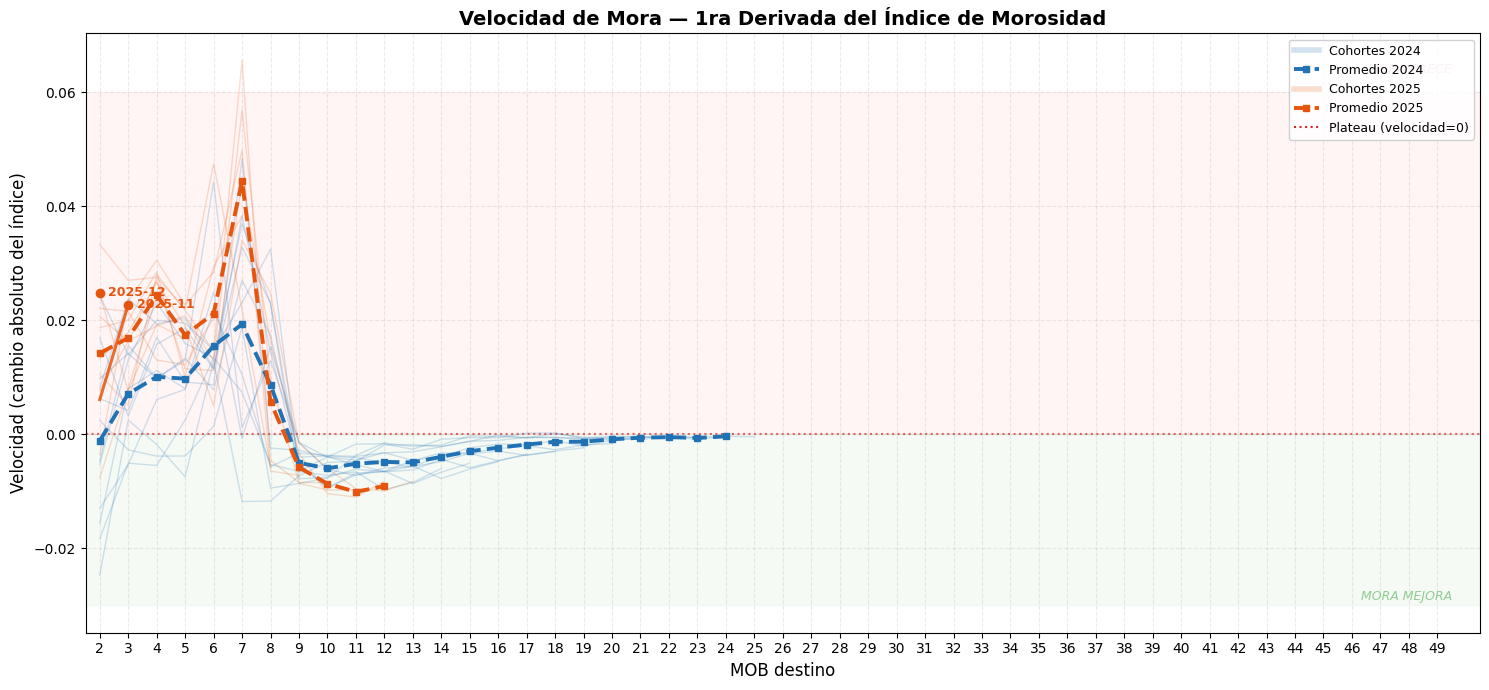

Gráfico guardado en reports/velocidad_mora.png


In [31]:
from matplotlib.lines import Line2D

COLOR_2024 = "#2171b5"
COLOR_2025 = "#e6550d"
ALPHA_IND = 0.20
ALPHA_HL = 0.85
N_DESTACAR = 3

cohortes_ord = sorted(velocidad.index)
ultimas_n = cohortes_ord[-N_DESTACAR:]
cohortes_2024 = [c for c in cohortes_ord if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ord if c.startswith("2025")]

def extraer_vel(cohorte):
    vals = velocidad.loc[cohorte].dropna()
    if len(vals) == 0:
        return [], np.array([])
    mobs = [int(t.split("->")[1]) for t in vals.index]
    return mobs, vals.values

def promedio_vel(cohortes):
    mobs_out, vals_out = [], []
    for col in velocidad.columns:
        vals = velocidad.loc[cohortes, col].dropna()
        if len(vals) >= 2:
            mobs_out.append(int(col.split("->")[1]))
            vals_out.append(vals.mean())
    return mobs_out, vals_out

pv_m24, pv_v24 = promedio_vel(cohortes_2024)
pv_m25, pv_v25 = promedio_vel(cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])

fig, ax = plt.subplots(figsize=(15, 7))

ax.axhline(y=0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7, zorder=0)
ax.axhspan(0, 0.06, alpha=0.04, color="red", zorder=0)
ax.axhspan(-0.03, 0, alpha=0.04, color="green", zorder=0)

for cohorte in cohortes_2024:
    mobs, vals = extraer_vel(cohorte)
    if not mobs:
        continue
    hl = cohorte in ultimas_n
    ax.plot(mobs, vals, color=COLOR_2024,
            alpha=ALPHA_HL if hl else ALPHA_IND,
            linewidth=2.2 if hl else 1.0, zorder=3 if hl else 1)

for cohorte in cohortes_2025:
    mobs, vals = extraer_vel(cohorte)
    if not mobs:
        continue
    hl = cohorte in ultimas_n
    ax.plot(mobs, vals, color=COLOR_2025,
            alpha=ALPHA_HL if hl else ALPHA_IND,
            linewidth=2.2 if hl else 1.0, zorder=3 if hl else 1)

if pv_m24:
    ax.plot(pv_m24, pv_v24, color=COLOR_2024, linewidth=2.8,
            linestyle="--", marker="s", markersize=5, zorder=4)
if pv_m25:
    ax.plot(pv_m25, pv_v25, color=COLOR_2025, linewidth=2.8,
            linestyle="--", marker="s", markersize=5, zorder=4)

for cohorte in ultimas_n:
    mobs, vals = extraer_vel(cohorte)
    if not mobs:
        continue
    color = COLOR_2024 if cohorte.startswith("2024") else COLOR_2025
    ax.annotate(cohorte, xy=(mobs[-1], vals[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center", zorder=5)
    ax.plot(mobs[-1], vals[-1], "o", color=color, markersize=6, zorder=5)

ax.text(0.98, 0.95, "MORA CRECE", transform=ax.transAxes, fontsize=9,
        ha="right", va="top", color="#d62728", alpha=0.5, fontstyle="italic")
ax.text(0.98, 0.05, "MORA MEJORA", transform=ax.transAxes, fontsize=9,
        ha="right", va="bottom", color="#2ca02c", alpha=0.5, fontstyle="italic")

ax.set_xlabel("MOB destino", fontsize=12)
ax.set_ylabel("Velocidad (cambio absoluto del índice)", fontsize=12)
ax.set_title("Velocidad de Mora — 1ra Derivada del Índice de Morosidad",
             fontsize=14, fontweight="bold")
mob_max = max(int(c.split("->")[1]) for c in velocidad.columns)
ax.set_xticks(range(2, mob_max + 1))
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_xlim(1.5, mob_max + 1.5)

legend_elements = [
    Line2D([0], [0], color=COLOR_2024, alpha=ALPHA_IND, lw=4, label="Cohortes 2024"),
    Line2D([0], [0], color=COLOR_2024, lw=2.8, ls="--", marker="s", markersize=5, label="Promedio 2024"),
    Line2D([0], [0], color=COLOR_2025, alpha=ALPHA_IND, lw=4, label="Cohortes 2025"),
]
if pv_m25:
    legend_elements.append(
        Line2D([0], [0], color=COLOR_2025, lw=2.8, ls="--", marker="s", markersize=5, label="Promedio 2025"))
legend_elements.append(
    Line2D([0], [0], color="#d62728", lw=1.5, ls=":", label="Plateau (velocidad=0)"))
ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "velocidad_mora.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/velocidad_mora.png")

### Diagnóstico de fase por cohorte (Velocidad + Factor combinados)

Panel izquierdo: **Velocidad** (1ra derivada, cambio absoluto).
Panel derecho: **Factor** (2da derivada, cambio relativo).

Juntos permiten identificar en qué fase del ciclo de vida está cada cosecha.


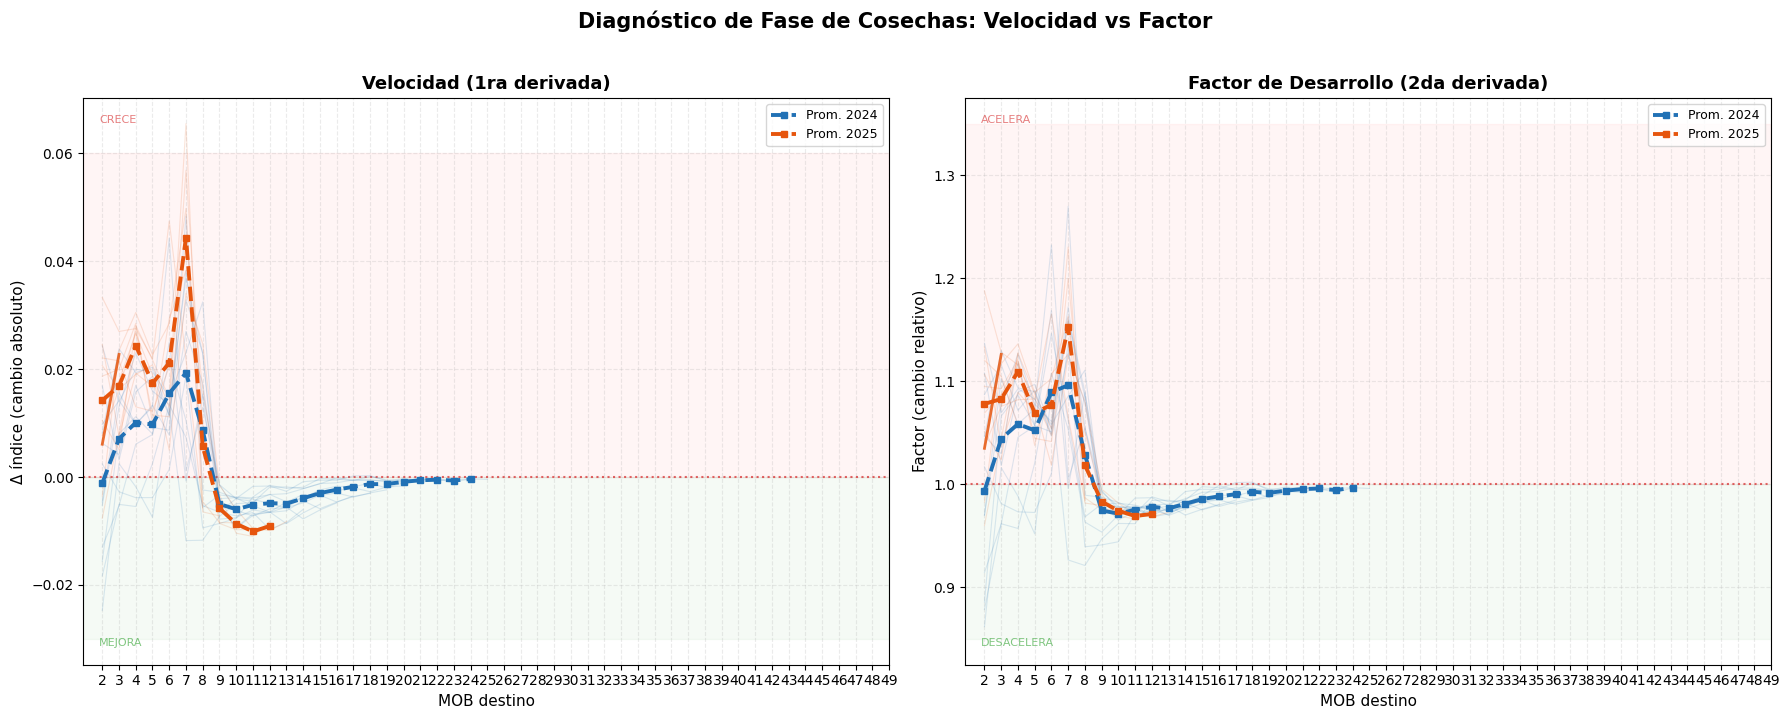

Gráfico guardado en reports/diagnostico_fases.png


In [32]:
# Panel combinado: Velocidad (izq) + Factor (der) con diagnóstico de fase
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# --- Recargar factores ---
factores = pd.read_csv(os.path.join(PROCESSED_DIR, "factores_desarrollo.csv"), sep=";", decimal=",", index_col=0)

cohortes_ord = sorted(velocidad.index)
ultimas_n = cohortes_ord[-3:]
cohortes_2024 = [c for c in cohortes_ord if c.startswith("2024")]
cohortes_2025 = [c for c in cohortes_ord if c.startswith("2025")]

# Promedios velocidad
def prom(df, cohortes):
    mo, vo = [], []
    for col in df.columns:
        v = df.loc[cohortes, col].dropna()
        if len(v) >= 2:
            mo.append(int(col.split("->")[1]))
            vo.append(v.mean())
    return mo, vo

pv_m24, pv_v24 = prom(velocidad, cohortes_2024)
pf_m24, pf_v24 = prom(factores, cohortes_2024)
pv_m25, pv_v25 = prom(velocidad, cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])
pf_m25, pf_v25 = prom(factores, cohortes_2025) if len(cohortes_2025) >= 2 else ([], [])

# ---- PANEL IZQUIERDO: Velocidad ----
ax1.axhline(y=0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7)
ax1.axhspan(0, 0.06, alpha=0.04, color="red")
ax1.axhspan(-0.03, 0, alpha=0.04, color="green")

for cohorte in cohortes_2024:
    v = velocidad.loc[cohorte].dropna()
    if len(v) == 0:
        continue
    mobs = [int(t.split("->")[1]) for t in v.index]
    hl = cohorte in ultimas_n
    ax1.plot(mobs, v.values, color=COLOR_2024,
             alpha=0.85 if hl else 0.15, linewidth=2.0 if hl else 0.8)

for cohorte in cohortes_2025:
    v = velocidad.loc[cohorte].dropna()
    if len(v) == 0:
        continue
    mobs = [int(t.split("->")[1]) for t in v.index]
    hl = cohorte in ultimas_n
    ax1.plot(mobs, v.values, color=COLOR_2025,
             alpha=0.85 if hl else 0.15, linewidth=2.0 if hl else 0.8)

if pv_m24:
    ax1.plot(pv_m24, pv_v24, color=COLOR_2024, lw=2.8, ls="--", marker="s", ms=4, label="Prom. 2024")
if pv_m25:
    ax1.plot(pv_m25, pv_v25, color=COLOR_2025, lw=2.8, ls="--", marker="s", ms=4, label="Prom. 2025")

ax1.set_title("Velocidad (1ra derivada)", fontsize=13, fontweight="bold")
ax1.set_xlabel("MOB destino", fontsize=11)
ax1.set_ylabel("\u0394 índice (cambio absoluto)", fontsize=11)
ax1.legend(fontsize=9, loc="upper right")
ax1.grid(True, alpha=0.25, linestyle="--")
mob_max = max(int(c.split("->")[1]) for c in velocidad.columns)
ax1.set_xticks(range(2, mob_max + 1))
ax1.text(0.02, 0.97, "CRECE", transform=ax1.transAxes, fontsize=8, color="#d62728", alpha=0.6, va="top")
ax1.text(0.02, 0.03, "MEJORA", transform=ax1.transAxes, fontsize=8, color="#2ca02c", alpha=0.6, va="bottom")

# ---- PANEL DERECHO: Factor ----
ax2.axhline(y=1.0, color="#d62728", linewidth=1.5, linestyle=":", alpha=0.7)
ax2.axhspan(1.0, 1.35, alpha=0.04, color="red")
ax2.axhspan(0.85, 1.0, alpha=0.04, color="green")

for cohorte in cohortes_2024:
    v = factores.loc[cohorte].dropna()
    if len(v) == 0:
        continue
    mobs = [int(t.split("->")[1]) for t in v.index]
    hl = cohorte in ultimas_n
    ax2.plot(mobs, v.values, color=COLOR_2024,
             alpha=0.85 if hl else 0.15, linewidth=2.0 if hl else 0.8)

for cohorte in cohortes_2025:
    v = factores.loc[cohorte].dropna()
    if len(v) == 0:
        continue
    mobs = [int(t.split("->")[1]) for t in v.index]
    hl = cohorte in ultimas_n
    ax2.plot(mobs, v.values, color=COLOR_2025,
             alpha=0.85 if hl else 0.15, linewidth=2.0 if hl else 0.8)

if pf_m24:
    ax2.plot(pf_m24, pf_v24, color=COLOR_2024, lw=2.8, ls="--", marker="s", ms=4, label="Prom. 2024")
if pf_m25:
    ax2.plot(pf_m25, pf_v25, color=COLOR_2025, lw=2.8, ls="--", marker="s", ms=4, label="Prom. 2025")

ax2.set_title("Factor de Desarrollo (2da derivada)", fontsize=13, fontweight="bold")
ax2.set_xlabel("MOB destino", fontsize=11)
ax2.set_ylabel("Factor (cambio relativo)", fontsize=11)
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(True, alpha=0.25, linestyle="--")
ax2.set_xticks(range(2, mob_max + 1))
ax2.text(0.02, 0.97, "ACELERA", transform=ax2.transAxes, fontsize=8, color="#d62728", alpha=0.6, va="top")
ax2.text(0.02, 0.03, "DESACELERA", transform=ax2.transAxes, fontsize=8, color="#2ca02c", alpha=0.6, va="bottom")

fig.suptitle("Diagnóstico de Fase de Cosechas: Velocidad vs Factor",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "diagnostico_fases.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/diagnostico_fases.png")

In [33]:
# Diagnóstico de fase para cada cohorte (basado en su última transición disponible)
print("DIAGNÓSTICO DE FASE POR COHORTE")
print("=" * 70)
print(f"{"Cohorte":>10s} | {"Última trans.":>13s} | {"Velocidad":>10s} | {"Factor":>8s} | Fase")
print("-" * 70)

for cohorte in sorted(velocidad.index):
    vel_vals = velocidad.loc[cohorte].dropna()
    fac_vals = factores.loc[cohorte].dropna()
    if len(vel_vals) == 0 or len(fac_vals) == 0:
        continue
    last_trans = vel_vals.index[-1]
    v = vel_vals.iloc[-1]
    f = fac_vals.iloc[-1]

    # Determinar fase
    if v > 0.005 and f > 1.02:
        fase = "DETERIORO (acelerando)"
    elif v > 0.005 and f <= 1.02:
        fase = "DESACELERACIÓN (cerca del plateau)"
    elif abs(v) <= 0.005:
        fase = "PLATEAU / MESETA"
    elif v < -0.005 and f < 0.98:
        fase = "CURACIÓN (mejorando)"
    else:
        fase = "ESTABILIZACIÓN"

    print(f"{cohorte:>10s} | {last_trans:>13s} | {v:>+10.4f} | {f:>8.4f} | {fase}")

print("=" * 70)


DIAGNÓSTICO DE FASE POR COHORTE
   Cohorte | Última trans. |  Velocidad |   Factor | Fase
----------------------------------------------------------------------
   2022-01 |        48->49 |    -0.0001 |   0.9982 | PLATEAU / MESETA
   2022-02 |        47->48 |    -0.0001 |   0.9986 | PLATEAU / MESETA
   2022-03 |        46->47 |    -0.0002 |   0.9978 | PLATEAU / MESETA
   2022-04 |        45->46 |    -0.0002 |   0.9976 | PLATEAU / MESETA
   2022-05 |        44->45 |    -0.0001 |   0.9985 | PLATEAU / MESETA
   2022-06 |        43->44 |    -0.0001 |   0.9988 | PLATEAU / MESETA
   2022-07 |        42->43 |    -0.0002 |   0.9968 | PLATEAU / MESETA
   2022-08 |        41->42 |    -0.0002 |   0.9963 | PLATEAU / MESETA
   2022-09 |        40->41 |    -0.0002 |   0.9963 | PLATEAU / MESETA
   2022-10 |        39->40 |    -0.0001 |   0.9977 | PLATEAU / MESETA
   2022-11 |        38->39 |    -0.0002 |   0.9957 | PLATEAU / MESETA
   2022-12 |        37->38 |    -0.0002 |   0.9971 | PLATEAU / MESETA

---
## 4. Índice de morosidad al mismo MOB (comparación entre cohortes)

Para comparar cohortes de forma justa, se mira el índice al mismo MOB.

In [34]:
# MOB de referencia: el máximo MOB que tienen todas las cohortes
mob_comun = matriz.dropna(axis=1).columns
mob_max_comun = mob_comun[-1]
print(f"MOB máximo común a todas las cohortes: {mob_max_comun}\n")

comparacion = matriz[mob_comun].copy()
comparacion["último_indice"] = matriz.apply(lambda row: row.dropna().iloc[-1], axis=1)
comparacion["mob_actual"] = matriz.apply(lambda row: row.dropna().index[-1], axis=1)

print("Índice de morosidad por cohorte (MOBs comunes + último disponible):")
comparacion[[mob_comun[0], mob_comun[-1], "mob_actual", "último_indice"]].style.format(
    {mob_comun[0]: "{:.2%}", mob_comun[-1]: "{:.2%}", "último_indice": "{:.2%}"}
)

MOB máximo común a todas las cohortes: MOB_1

Índice de morosidad por cohorte (MOBs comunes + último disponible):


,MOB_1,MOB_1,mob_actual,último_indice
cohorte,,,,
2022-01,12.08%,12.08%,MOB_49,8.13%
2022-02,11.61%,11.61%,MOB_48,7.80%
2022-03,11.09%,11.09%,MOB_47,7.86%
2022-04,12.15%,12.15%,MOB_46,7.81%
2022-05,10.65%,10.65%,MOB_45,7.26%
2022-06,9.17%,9.17%,MOB_44,7.35%
2022-07,11.39%,11.39%,MOB_43,6.78%
2022-08,10.13%,10.13%,MOB_42,6.26%
2022-09,9.60%,9.60%,MOB_41,6.12%


---
## 5. Evolución del monto moroso por cohorte

C:\Users\skannema\AppData\Local\Temp\ipykernel_75412\2631228977.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


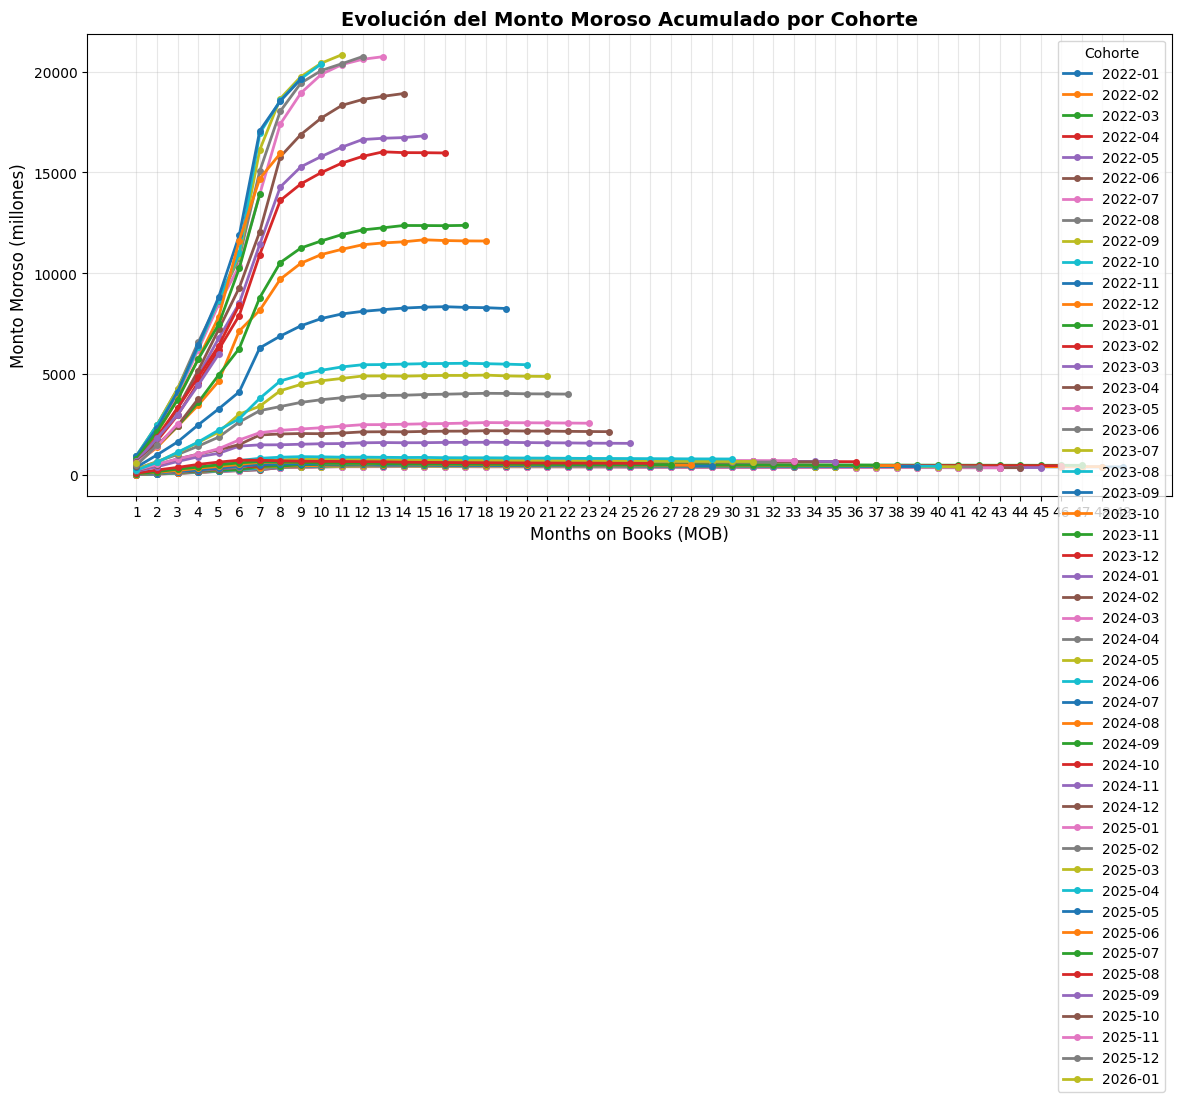

Gráfico guardado en reports/monto_moroso.png


In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

for cohorte, grupo in df.groupby("cohorte"):
    ax.plot(grupo["mob"], grupo["moroso"] / 1e6, marker="o", markersize=4, linewidth=2, label=cohorte)

ax.set_xlabel("Months on Books (MOB)", fontsize=12)
ax.set_ylabel("Monto Moroso (millones)", fontsize=12)
ax.set_title("Evolución del Monto Moroso Acumulado por Cohorte", fontsize=14, fontweight="bold")
ax.legend(title="Cohorte", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, int(df['mob'].max()) + 1))
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "reports", "monto_moroso.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/monto_moroso.png")

---
## 6. Resumen Ejecutivo

In [36]:
print("=" * 60)
print("RESUMEN EJECUTIVO - ANÁLISIS VINTAGE")
print("=" * 60)

for cohorte, grupo in df.groupby("cohorte"):
    ultimo = grupo.iloc[-1]
    print(f"\nCohorte {cohorte}:")
    print(f"  MOB actual:          {int(ultimo['mob'])}")
    print(f"  Índice actual:       {ultimo['indice']:.2%}")
    print(f"  Índice máximo:       {grupo['indice'].max():.2%} (MOB {int(grupo.loc[grupo['indice'].idxmax(), 'mob'])})")
    print(f"  Índice mínimo:       {grupo['indice'].min():.2%} (MOB {int(grupo.loc[grupo['indice'].idxmin(), 'mob'])})")
    print(f"  Total vencido:       ${ultimo['total_vencido']:,.0f}")
    print(f"  Monto moroso:        ${ultimo['moroso']:,.0f}")
    tendencia = "DESCENDENTE" if ultimo['indice'] < grupo['indice'].max() else "EN MÁXIMO"
    print(f"  Tendencia:           {tendencia}")

print("\n" + "=" * 60)

RESUMEN EJECUTIVO - ANÁLISIS VINTAGE

Cohorte 2022-01:
  MOB actual:          49
  Índice actual:       8.13%
  Índice máximo:       16.15% (MOB 9)
  Índice mínimo:       8.13% (MOB 49)
  Total vencido:       $4,968,913,074
  Monto moroso:        $404,138,925
  Tendencia:           DESCENDENTE

Cohorte 2022-02:
  MOB actual:          48
  Índice actual:       7.80%
  Índice máximo:       16.30% (MOB 8)
  Índice mínimo:       7.80% (MOB 48)
  Total vencido:       $5,343,929,417
  Monto moroso:        $416,960,957
  Tendencia:           DESCENDENTE

Cohorte 2022-03:
  MOB actual:          47
  Índice actual:       7.86%
  Índice máximo:       16.17% (MOB 8)
  Índice mínimo:       7.86% (MOB 47)
  Total vencido:       $6,135,672,552
  Monto moroso:        $482,209,720
  Tendencia:           DESCENDENTE

Cohorte 2022-04:
  MOB actual:          46
  Índice actual:       7.81%
  Índice máximo:       15.33% (MOB 7)
  Índice mínimo:       7.81% (MOB 46)
  Total vencido:       $5,944,383,356
  